# Adorno's Critique in the Age of the 'For You' Page
## An NLP Pipeline Walkthrough

> *Interactive companion notebook to the academic paper.*  
> Walk through every stage of the pipeline — from raw YouTube comments to Adorno-grounded critique classification.

---

## Section 0 · Setup & Imports

In [1]:
import json
import re
import sys
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# --- display settings ---
pd.set_option('display.max_colwidth', 200)
pd.set_option('display.max_rows', 50)

matplotlib.rcParams.update({
    'figure.facecolor': '#fafafa',
    'axes.facecolor':   '#f5f5f5',
    'axes.grid':        True,
    'grid.color':       'white',
    'grid.linewidth':   0.8,
    'font.family':      'DejaVu Sans',
    'figure.dpi':       120,
})

# --- absolute base paths ---
BASE = Path('/Users/lfpmb/Documents/testing-adorno')
PIPELINE = BASE / 'nlp_pipeline'
OUTPUTS  = PIPELINE / 'outputs'

print('Setup complete.')
print(f'Base dir : {BASE}')
print(f'Pipeline : {PIPELINE}')
print(f'Outputs  : {OUTPUTS}')

Setup complete.
Base dir : /Users/lfpmb/Documents/testing-adorno
Pipeline : /Users/lfpmb/Documents/testing-adorno/nlp_pipeline
Outputs  : /Users/lfpmb/Documents/testing-adorno/nlp_pipeline/outputs


---

## Section 1 · Theoretical Framework

### Adorno's Culture Industry

Theodor W. Adorno and Max Horkheimer coined the term **Culture Industry** in *Dialectic of Enlightenment* (1944) to describe how capitalist mass production had colonised cultural life. Far from being a space of free expression, popular culture — including popular music — had become a factory, producing standardised commodities that masquerade as individual, spontaneous, and emotionally authentic.

Adorno's critique has six key dimensions, operationalised here as NLP classification labels:

| Label | Short Description | Adorno's Concept |
|---|---|---|
| **STANDARDIZATION** | Formulaic, repetitive, interchangeable songs | Songs share identical verse-chorus templates; novelty is illusion |
| **PSEUDO_INDIVIDUALIZATION** | Fake uniqueness masking sameness | Superficial stylistic touches sold as authentic artistic identity |
| **COMMODIFICATION_MARKET_LOGIC** | Chart/algorithm/label critique | Music treated as a product optimised for profit, not expression |
| **REGRESSIVE_LISTENING** | Passive, background, shallow consumption | Listeners atrophied into consumers who cannot engage critically |
| **AFFECTIVE_PREPACKAGING** | Engineered / manufactured emotion | Emotional responses are pre-designed by producers, not felt |
| **FORMAL_RESISTANCE** | Complexity / anti-formula / genuine art | *Counter-evidence* — moments that genuinely resist the Culture Industry |

### Research Question

> *Do YouTube comment sections on the 15 most-streamed songs of 2025 contain evidence of Adorno's Culture Industry critique — and if so, which dimensions appear most prominently?*

We answer this by applying a four-stage NLP pipeline (preprocessing → rule-based weak labelling → embedding similarity → LLM adjudication) to **84,816 comments** drawn from **209,049** total collected records.

---

## Section 2 · Dataset Overview

In [2]:
# --- load raw comments ---
RAW_PATH = BASE / 'youtube_comments_merged.json'

try:
    with open(RAW_PATH, 'r', encoding='utf-8') as f:
        raw_data = json.load(f)
    df_raw = pd.DataFrame(raw_data)
    print(f'Total comments loaded : {len(df_raw):,}')
    print(f'Columns               : {list(df_raw.columns)}')
except Exception as e:
    print(f'Error loading data: {e}')
    df_raw = pd.DataFrame()

Total comments loaded : 209,049
Columns               : ['cid', 'text', 'time', 'author', 'channel', 'votes', 'replies', 'photo', 'heart', 'reply', 'time_parsed', 'song_title', 'artists', 'youtube_url']


In [3]:
# --- sample of 5 comments ---
if not df_raw.empty:
    display_cols = [c for c in ['cid', 'text', 'author', 'votes', 'replies'] if c in df_raw.columns]
    sample = df_raw[display_cols].dropna(subset=['text']).head(5)
    display(sample.style.set_caption('Sample of 5 YouTube Comments'))
else:
    print('DataFrame is empty — cannot display sample.')

,cid,text,author,votes,replies
0,UgwUx9K_ayf25j0vmyR4AaABAg,SUPER BOWL BABY,@djmanuelmares,2K,62
1,UgzCAM0yqjHtwb24xD14AaABAg,anyone here because lady gaga performed die with a smile in the super bowl,@fiorellayucra-c6d,1.6K,65
2,UgxccWOpZ2W-BhYHxBh4AaABAg,Real music is COMING BACK 😭🙏🏽,@Daniilvzu,25K,148
3,UgwzP_mXRg6CZ-DZgiV4AaABAg,"Drops a banger, disappears for two years, comes back, repeat. He can't keep getting away with this 😭😭",@AWildRaito,53K,223
4,Ugxudk1MvlJFISWnzGd4AaABAg,i love how gaga manages to look like a new person nearly everyday,@woweric,31K,117


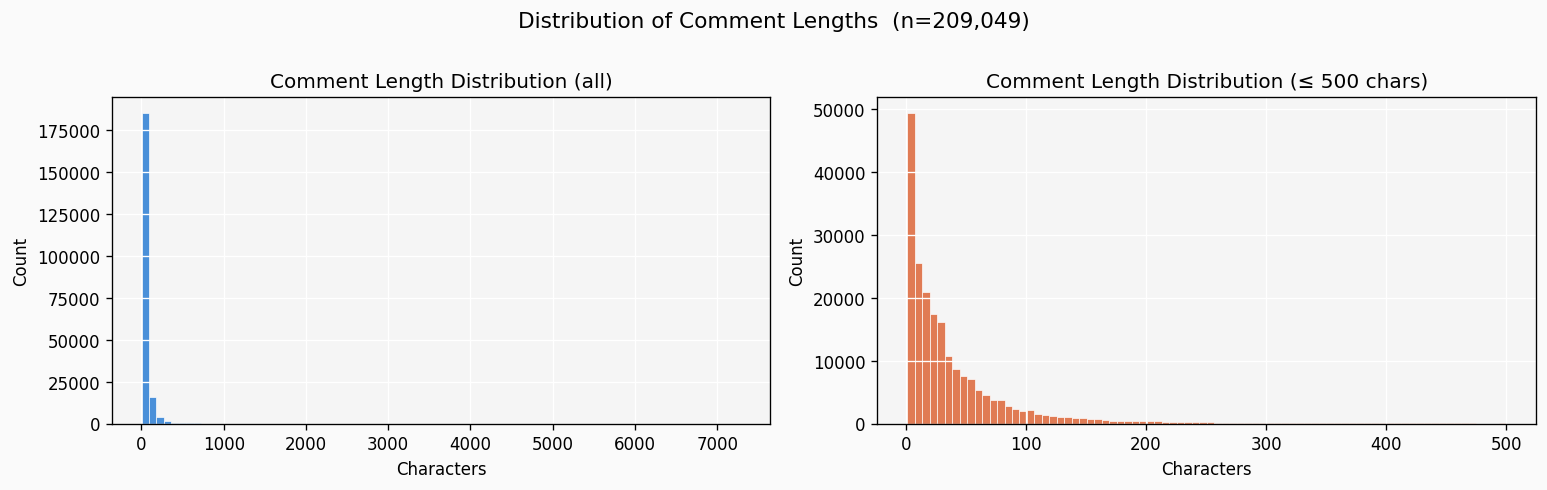


Length statistics:
count    209049.000000
mean         46.034987
std         106.377630
min           1.000000
25%           8.000000
50%          22.000000
75%          51.000000
max        7282.000000


In [4]:
# --- distribution of comment lengths ---
if not df_raw.empty and 'text' in df_raw.columns:
    lengths = df_raw['text'].dropna().str.len()

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # full range
    axes[0].hist(lengths, bins=80, color='#4a90d9', edgecolor='white', linewidth=0.4)
    axes[0].set_title('Comment Length Distribution (all)', fontsize=12)
    axes[0].set_xlabel('Characters')
    axes[0].set_ylabel('Count')

    # truncated at 500 chars for readability
    axes[1].hist(lengths[lengths <= 500], bins=80, color='#e07b54', edgecolor='white', linewidth=0.4)
    axes[1].set_title('Comment Length Distribution (≤ 500 chars)', fontsize=12)
    axes[1].set_xlabel('Characters')
    axes[1].set_ylabel('Count')

    plt.suptitle(f'Distribution of Comment Lengths  (n={len(lengths):,})', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

    print(f'\nLength statistics:')
    print(lengths.describe().to_string())
else:
    print('Cannot compute lengths — data unavailable.')

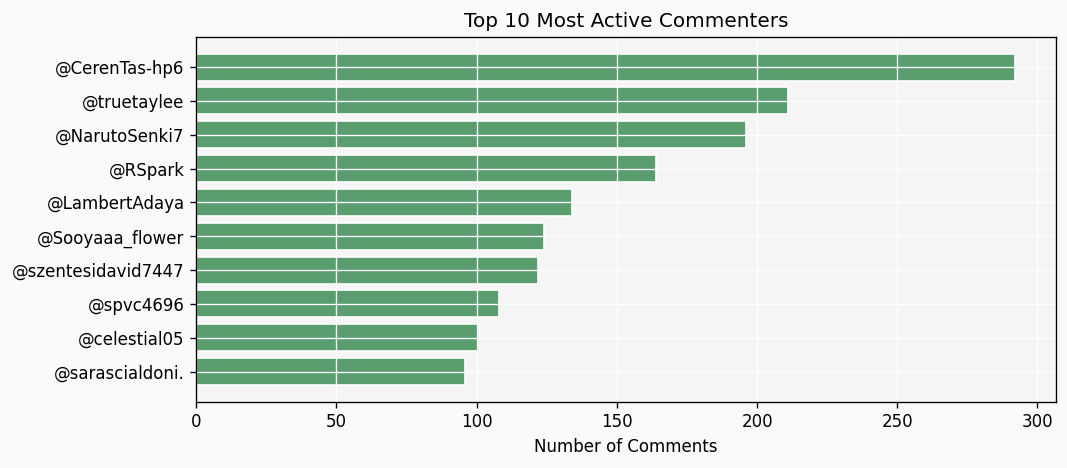

,Author,Comment Count
0,@CerenTas-hp6,292
1,@truetaylee,211
2,@NarutoSenki7,196
3,@RSpark,164
4,@LambertAdaya,134
5,@Sooyaaa_flower,124
6,@szentesidavid7447,122
7,@spvc4696,108
8,@celestial05,101
9,@sarascialdoni.,96


In [5]:
# --- top 10 most active commenters ---
if not df_raw.empty and 'author' in df_raw.columns:
    top_commenters = (
        df_raw['author']
        .dropna()
        .value_counts()
        .head(10)
        .reset_index()
    )
    top_commenters.columns = ['Author', 'Comment Count']

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.barh(top_commenters['Author'][::-1], top_commenters['Comment Count'][::-1],
            color='#5a9e6f', edgecolor='white')
    ax.set_title('Top 10 Most Active Commenters', fontsize=12)
    ax.set_xlabel('Number of Comments')
    plt.tight_layout()
    plt.show()

    display(top_commenters)
else:
    print('Author column not available.')

---

## Section 3 · Preprocessing Pipeline

Stage 1 of the pipeline cleans raw comment text while deliberately **preserving the commenter's voice** — no aggressive lowercasing or slang removal. This section shows the actual source code and then demonstrates it on a small sample.

In [6]:
# --- display the actual preprocess.py source ---
PREPROCESS_PATH = PIPELINE / 'src' / 'preprocess.py'

try:
    source_code = PREPROCESS_PATH.read_text(encoding='utf-8')
    print(source_code)
except Exception as e:
    print(f'Could not read preprocess.py: {e}')

"""Stage 1: Text preprocessing for YouTube comment critique detection.

This module provides utilities to clean, normalize, and extract features from
raw YouTube comment text.  It is designed as the first stage in an NLP pipeline
that ultimately classifies whether a comment contains meaningful musical
critique.

Key design choices
------------------
* **Preserve voice** -- We deliberately avoid aggressive lowercasing or slang
  removal so that downstream models can leverage the commenter's authentic
  register (e.g. ALL-CAPS emphasis, slang like "fire", "mid", "slaps").
* **Dual-text columns** -- Every row retains both ``raw_text`` (verbatim from
  YouTube) and ``clean_text`` (after normalization) so that either can be used
  depending on the task.
* **Graceful failure** -- Language detection and emoji counting are wrapped in
  safe helpers that never raise; they log warnings and fall back to sensible
  defaults.
"""

from __future__ import annotations

import html
import re
import uni

In [7]:
# --- demonstrate clean_text and extract_features on a sample ---

SAMPLE_COMMENTS = [
    "This song is literally on EVERY playlist now, it's impossible to escape 😭😭😭",
    "The label clearly manufactured this hit for the TikTok algorithm, not real music!",
    "I just put this on in the background while I work, never really listen properly",
    "Real music died when streaming took over. Everything sounds the same nowadays.",
    "Actually the chord progression here is genuinely unusual for pop — resists formula!",
]

df_demo = pd.DataFrame({'text': SAMPLE_COMMENTS})

# attempt live import; fall back to static display if pipeline deps unavailable
try:
    if str(PIPELINE) not in sys.path:
        sys.path.insert(0, str(PIPELINE))
    from src.preprocess import clean_text, extract_features  # noqa: E402

    df_demo['clean_text'] = df_demo['text'].apply(clean_text)
    features = df_demo['clean_text'].apply(extract_features)
    df_features = pd.concat([df_demo, pd.DataFrame(features.tolist())], axis=1)

    print('✓  Pipeline imported successfully — live results below:')
    display(df_features)

except ImportError as e:
    print(f'ImportError: {e}')
    print('\nShowing static description of what clean_text does instead:\n')
    print('clean_text pipeline steps:')
    print('  1. NFKC unicode normalisation + double HTML-entity unescaping')
    print('  2. Remove http(s):// and www. URLs')
    print('  3. Remove @mentions')
    print('  4. Collapse runs of whitespace to a single space')
    print('\nextract_features returns:')
    for feat in ['text_length', 'word_count', 'punctuation_ratio',
                 'caps_ratio', 'emoji_count', 'exclamation_count', 'question_mark_count']:
        print(f'  - {feat}')
    display(df_demo)

✓  Pipeline imported successfully — live results below:


,text,clean_text,text_length,word_count,punctuation_ratio,caps_ratio,emoji_count,exclamation_count,question_mark_count
0,"This song is literally on EVERY playlist now, it's impossible to escape 😭😭😭","This song is literally on EVERY playlist now, it's impossible to escape 😭😭😭",75,13,0.0267,0.1034,3,0,0
1,"The label clearly manufactured this hit for the TikTok algorithm, not real music!","The label clearly manufactured this hit for the TikTok algorithm, not real music!",81,13,0.0247,0.0448,0,1,0
2,"I just put this on in the background while I work, never really listen properly","I just put this on in the background while I work, never really listen properly",79,15,0.0127,0.0312,0,0,0
3,Real music died when streaming took over. Everything sounds the same nowadays.,Real music died when streaming took over. Everything sounds the same nowadays.,78,12,0.0256,0.0308,0,0,0
4,Actually the chord progression here is genuinely unusual for pop — resists formula!,Actually the chord progression here is genuinely unusual for pop — resists formula!,83,13,0.0241,0.0145,0,1,0


---

## Section 4 · Label Taxonomy Deep Dive

In [8]:
# --- load labels.yaml ---
LABELS_PATH = PIPELINE / 'configs' / 'labels.yaml'

try:
    import yaml
    with open(LABELS_PATH, 'r') as f:
        labels_config = yaml.safe_load(f)
    print('labels.yaml loaded successfully.')
except ImportError:
    # manual parse fallback
    labels_config = None
    print('PyYAML not available; loading manually.')
except Exception as e:
    labels_config = None
    print(f'Error: {e}')

# display raw YAML
try:
    raw_yaml = LABELS_PATH.read_text()
    print('\n--- labels.yaml (raw) ---')
    print(raw_yaml)
except Exception as e:
    print(f'Could not read labels.yaml: {e}')

labels.yaml loaded successfully.

--- labels.yaml (raw) ---
# Label taxonomy for Adorno-grounded critique detection
# Multi-label: a comment may have 0..N critique labels.
# NONE is set automatically when all critique labels are false.

labels:
  STANDARDIZATION:
    id: 0
    description: >
      Claims that songs are formulaic, repetitive, template-driven,
      or structurally interchangeable. Invokes sameness across the
      catalogue rather than within a single song's internal repetition.
    short: "formulaic / same / template"
    min_confidence: 0.50
    target_precision: 0.80

  PSEUDO_INDIVIDUALIZATION:
    id: 1
    description: >
      Claims of superficial uniqueness masking underlying sameness.
      The "brand" or "style" of an artist is recognized as a marketing
      veneer rather than genuine artistic distinction.
    short: "fake uniqueness / branding veneer"
    min_confidence: 0.50
    target_precision: 0.75

  COMMODIFICATION_MARKET_LOGIC:
    id: 2
    descripti

In [9]:
# --- formatted label table ---
LABEL_DESCRIPTIONS = {
    'STANDARDIZATION': {
        'id': 0,
        'short': 'formulaic / same / template',
        'description': 'Songs are formulaic, repetitive, template-driven, or structurally interchangeable.',
        'min_confidence': 0.50,
        'target_precision': 0.80,
    },
    'PSEUDO_INDIVIDUALIZATION': {
        'id': 1,
        'short': 'fake uniqueness / branding veneer',
        'description': 'Superficial uniqueness masking underlying sameness; brand as marketing veneer.',
        'min_confidence': 0.50,
        'target_precision': 0.75,
    },
    'COMMODIFICATION_MARKET_LOGIC': {
        'id': 2,
        'short': 'chart / algorithm / label / virality critique',
        'description': 'Chart optimisation, algorithmic promotion, treating music as product not art.',
        'min_confidence': 0.50,
        'target_precision': 0.80,
    },
    'REGRESSIVE_LISTENING': {
        'id': 3,
        'short': 'passive / background / shallow listening',
        'description': 'Passive, background, low-attention, or non-critical consumption patterns.',
        'min_confidence': 0.45,
        'target_precision': 0.70,
    },
    'AFFECTIVE_PREPACKAGING': {
        'id': 4,
        'short': 'engineered / fake emotion',
        'description': 'Emotion is engineered, prefabricated, or manipulative; pre-designed by producers.',
        'min_confidence': 0.45,
        'target_precision': 0.70,
    },
    'FORMAL_RESISTANCE': {
        'id': 5,
        'short': 'complexity / anti-formula / genuine art',
        'description': 'Genuine complexity, anti-formula elements, resistance to easy consumption. Counter-evidence.',
        'min_confidence': 0.40,
        'target_precision': 0.65,
    },
}

df_labels = pd.DataFrame(LABEL_DESCRIPTIONS).T.reset_index()
df_labels.columns = ['Label', 'ID', 'Short', 'Description', 'Min Confidence', 'Target Precision']
display(df_labels[['Label', 'Short', 'Description', 'Min Confidence', 'Target Precision']])

,Label,Short,Description,Min Confidence,Target Precision
0,STANDARDIZATION,formulaic / same / template,"Songs are formulaic, repetitive, template-driven, or structurally interchangeable.",0.5,0.8
1,PSEUDO_INDIVIDUALIZATION,fake uniqueness / branding veneer,Superficial uniqueness masking underlying sameness; brand as marketing veneer.,0.5,0.75
2,COMMODIFICATION_MARKET_LOGIC,chart / algorithm / label / virality critique,"Chart optimisation, algorithmic promotion, treating music as product not art.",0.5,0.8
3,REGRESSIVE_LISTENING,passive / background / shallow listening,"Passive, background, low-attention, or non-critical consumption patterns.",0.45,0.7
4,AFFECTIVE_PREPACKAGING,engineered / fake emotion,"Emotion is engineered, prefabricated, or manipulative; pre-designed by producers.",0.45,0.7
5,FORMAL_RESISTANCE,complexity / anti-formula / genuine art,"Genuine complexity, anti-formula elements, resistance to easy consumption. Counter-evidence.",0.4,0.65


In [10]:
# --- example comments per label from sample_critique_matches.json ---
MATCHES_PATH = OUTPUTS / 'sample_critique_matches.json'

try:
    with open(MATCHES_PATH, 'r', encoding='utf-8') as f:
        sample_matches = json.load(f)

    print('Example comments per label (top 3 by confidence)\n')
    for label, examples in sample_matches.items():
        if not examples:
            continue
        sorted_ex = sorted(examples, key=lambda x: x.get('confidence', 0), reverse=True)
        top3 = sorted_ex[:3]
        print(f'{'─'*70}')
        print(f'  {label}')
        print(f'{'─'*70}')
        for i, ex in enumerate(top3, 1):
            conf = ex.get('confidence', 'N/A')
            text = ex.get('text', '')
            print(f'  [{i}] conf={conf:.3f}  {text[:160]}')
        print()

except Exception as e:
    print(f'Could not load sample matches: {e}')

Example comments per label (top 3 by confidence)

──────────────────────────────────────────────────────────────────────
  STANDARDIZATION
──────────────────────────────────────────────────────────────────────
  [1] conf=0.850  It is literally the exact same beat and melody in every single song. How do people listen to this slop?
  [2] conf=0.850  No. This is basic, four chord pop. It's the same chord progressions found in "I'm Not OK, I Promise" by My Chemical Romance. Thriller is a "masterpiece."
  [3] conf=0.850  ​'s most new songs these days clips of regurgitated sounds from really legendary classic songs however I actually like this song jahahahah

──────────────────────────────────────────────────────────────────────
  PSEUDO_INDIVIDUALIZATION
──────────────────────────────────────────────────────────────────────
  [1] conf=0.880  It’s giving manufactured personality

──────────────────────────────────────────────────────────────────────
  COMMODIFICATION_MARKET_LOGIC
───────────

---

## Section 5 · Pipeline Architecture

The classification system is a **four-stage ensemble pipeline**. Each stage acts as a filter, progressively narrowing the comment pool to those most likely to contain Adorno-grounded critique.

```
┌─────────────────────────────────────────────────────────────────────────┐
│                      NLP CRITIQUE DETECTION PIPELINE                    │
└─────────────────────────────────────────────────────────────────────────┘

 INPUT
   │  209,049 raw YouTube comments
   ▼
╔══════════════════════════════╗
║  STAGE 1: PREPROCESSING      ║
║  preprocess.py               ║
║  · NFKC normalisation        ║
║  · HTML entity decode        ║
║  · URL / @mention removal    ║
║  · Whitespace collapse       ║
║  · Trivial comment flagging  ║
║  · Feature extraction        ║
╚══════════════╤═══════════════╝
               │  cleaned text + features
               ▼
╔══════════════════════════════╗
║  STAGE 2: RULE-BASED WEAK    ║
║  LABELLING                   ║
║  weak_label_llm.py           ║
║  · Regex + keyword rules     ║
║  · Per-label rule sets       ║
║  · Confidence thresholding   ║
║  · 208 rule hits / 209K rows ║
╚══════════════╤═══════════════╝
               │  weak labels + confidences
               ▼
╔══════════════════════════════╗
║  STAGE 3: EMBEDDING          ║
║  SIMILARITY                  ║
║  · Prototype comment embeds  ║
║  · Cosine similarity search  ║
║  · Prototype-based labelling ║
║  · Ensemble voting           ║
╚══════════════╤═══════════════╝
               │  ensemble predictions
               ▼
╔══════════════════════════════╗
║  STAGE 4: LLM ADJUDICATION   ║
║  · Low-confidence cases →    ║
║    human_review queue        ║
║  · Final label assignment    ║
║  · 368 critique detections   ║
╚══════════════╤═══════════════╝
               │
 OUTPUT
   │  critique_detections.jsonl
   ▼  368 labelled comments, 6 Adorno critique dimensions
```

**Key design choices:**
- *Preserve voice* — no lowercasing or slang removal, keeping ALL-CAPS emphasis and idioms
- *Multi-label* — a comment may carry multiple critique labels simultaneously
- *NONE label* — auto-assigned when no critique dimension triggers (fan reactions, lyric quotes, spam)
- *FORMAL_RESISTANCE* — inverse polarity label; high confidence here is counter-evidence to Adorno

---

## Section 6 · Results: Label Distribution

In [11]:
# --- load critique_detections.jsonl ---
DETECTIONS_PATH = OUTPUTS / 'critique_detections.jsonl'

detections = []
try:
    with open(DETECTIONS_PATH, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                detections.append(json.loads(line))
    df_det = pd.DataFrame(detections)
    print(f'Loaded {len(df_det)} detections.')
    print(f'Columns: {list(df_det.columns)}')
except Exception as e:
    print(f'Error loading detections: {e}')
    df_det = pd.DataFrame()

Loaded 368 detections.
Columns: ['comment_id', 'raw_text', 'predicted_labels', 'label_probs', 'evidence', 'decision_path', 'needs_human_review']


,Label,Count,Pct of Detections
0,STANDARDIZATION,84,22.8
1,PSEUDO_INDIVIDUALIZATION,0,0.0
2,COMMODIFICATION_MARKET_LOGIC,55,14.9
3,REGRESSIVE_LISTENING,35,9.5
4,AFFECTIVE_PREPACKAGING,20,5.4
5,FORMAL_RESISTANCE,189,51.4


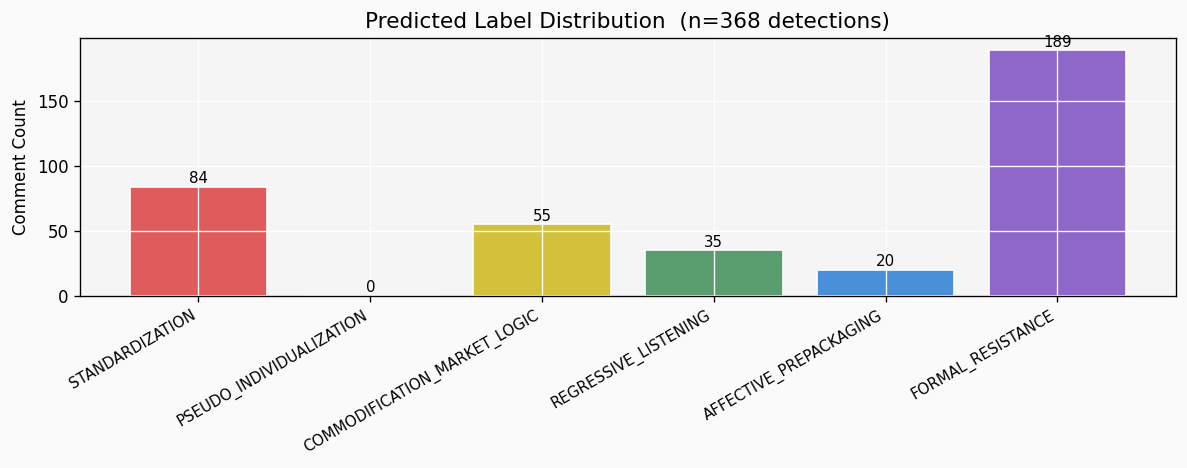

In [12]:
# --- count by predicted label ---
LABEL_ORDER = [
    'STANDARDIZATION', 'PSEUDO_INDIVIDUALIZATION', 'COMMODIFICATION_MARKET_LOGIC',
    'REGRESSIVE_LISTENING', 'AFFECTIVE_PREPACKAGING', 'FORMAL_RESISTANCE'
]
LABEL_COLORS = {
    'STANDARDIZATION':           '#e05c5c',
    'PSEUDO_INDIVIDUALIZATION':  '#e09a3e',
    'COMMODIFICATION_MARKET_LOGIC': '#d4c13b',
    'REGRESSIVE_LISTENING':      '#5a9e6f',
    'AFFECTIVE_PREPACKAGING':    '#4a90d9',
    'FORMAL_RESISTANCE':         '#8e67c8',
}

label_counts = Counter()
if not df_det.empty and 'predicted_labels' in df_det.columns:
    for labels in df_det['predicted_labels']:
        if isinstance(labels, list):
            for lbl in labels:
                label_counts[lbl] += 1
        elif isinstance(labels, str):
            label_counts[labels] += 1

total_det = len(df_det) if not df_det.empty else 0

# build summary table
rows = []
for lbl in LABEL_ORDER:
    cnt = label_counts.get(lbl, 0)
    pct = (cnt / total_det * 100) if total_det > 0 else 0
    rows.append({'Label': lbl, 'Count': cnt, 'Pct of Detections': round(pct, 1)})
df_dist = pd.DataFrame(rows)
display(df_dist)

# bar chart
fig, ax = plt.subplots(figsize=(10, 4))
colors = [LABEL_COLORS.get(l, '#aaa') for l in df_dist['Label']]
bars = ax.bar(df_dist['Label'], df_dist['Count'], color=colors, edgecolor='white')
ax.set_title(f'Predicted Label Distribution  (n={total_det} detections)', fontsize=13)
ax.set_ylabel('Comment Count')
ax.set_xlabel('')
plt.xticks(rotation=30, ha='right', fontsize=9)
for bar, val in zip(bars, df_dist['Count']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(val), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

Total rows scanned : 209,049
Any rule hit       : 208  (0.1%)



,Label,Rule Hits,Hit %,Avg Confidence
0,STANDARDIZATION,69,0.03,0.8080
1,PSEUDO_INDIVIDUALIZATION,1,0.00,0.8800
2,COMMODIFICATION_MARKET_LOGIC,51,0.02,0.8076
3,REGRESSIVE_LISTENING,17,0.01,0.8200
4,AFFECTIVE_PREPACKAGING,18,0.01,0.7956
5,FORMAL_RESISTANCE,53,0.03,0.6638


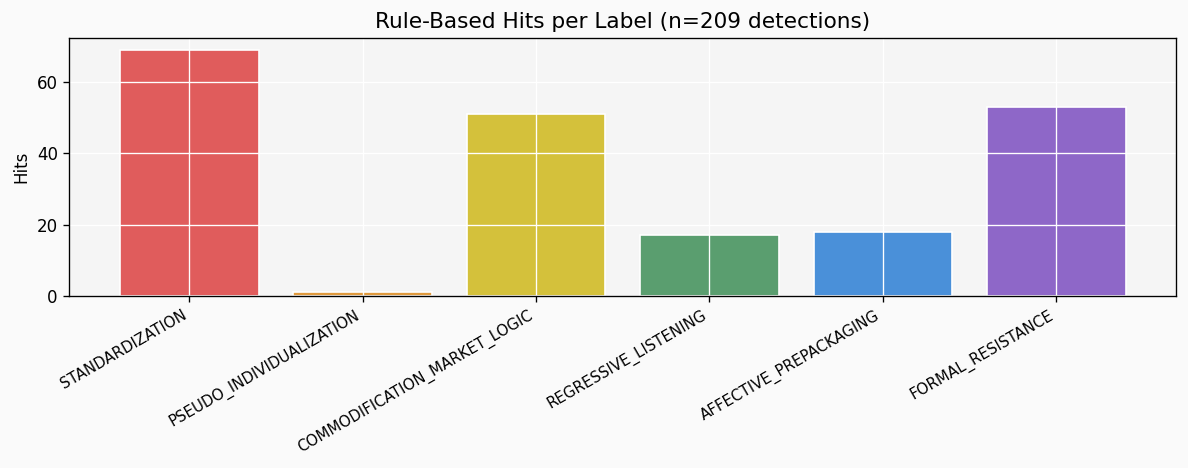

In [25]:
# --- rule-based hit counts from rule_coverage_report.json ---
RULE_COV_PATH = OUTPUTS / 'rule_coverage_report.json'

try:
    with open(RULE_COV_PATH, 'r') as f:
        rule_cov = json.load(f)

    print(f"Total rows scanned : {rule_cov.get('total_rows', 'N/A'):,}")
    print(f"Any rule hit       : {rule_cov.get('any_rule_hit', 'N/A'):,}  "
          f"({rule_cov.get('any_rule_hit_pct', 0):.1f}%)")
    print()

    per_label = rule_cov.get('per_label', {})
    rule_rows = []
    for lbl in LABEL_ORDER:
        info = per_label.get(lbl, {})
        rule_rows.append({
            'Label': lbl,
            'Rule Hits': info.get('hits', 0),
            'Hit %': info.get('hit_pct', 0),
            'Avg Confidence': info.get('avg_confidence', 0),
        })
    df_rules = pd.DataFrame(rule_rows)
    display(df_rules)

    total_det_1 = df_rules['Rule Hits'].sum()

    # comparison chart
    fig, ax = plt.subplots(figsize=(10, 4))
    x = range(len(LABEL_ORDER))
    ax.bar(x, df_rules['Rule Hits'], color=[LABEL_COLORS.get(l, '#aaa') for l in LABEL_ORDER],
           edgecolor='white')
    ax.set_xticks(list(x))
    ax.set_xticklabels(LABEL_ORDER, rotation=30, ha='right', fontsize=9)
    ax.set_title(f'Rule-Based Hits per Label (n={total_det_1} detections)', fontsize=13)
    ax.set_ylabel('Hits')
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f'Could not load rule coverage report: {e}')

---

## Section 7 · Deep Dive: Standardization

In [14]:
# --- top 5 highest-confidence STANDARDIZATION examples ---
LABEL = 'STANDARDIZATION'

std_comments = []
if not df_det.empty:
    for _, row in df_det.iterrows():
        labels = row.get('predicted_labels', [])
        if isinstance(labels, list) and LABEL in labels:
            probs = row.get('label_probs', {})
            conf = probs.get(LABEL, 0) if isinstance(probs, dict) else 0
            std_comments.append({'text': row.get('raw_text', ''), 'confidence': conf})

df_std = pd.DataFrame(std_comments).sort_values('confidence', ascending=False)
print(f'Total STANDARDIZATION detections: {len(df_std)}')
print('\nTop 5 by confidence:')
display(df_std.head(5).reset_index(drop=True))

Total STANDARDIZATION detections: 84

Top 5 by confidence:


,text,confidence
0,It's just like every generic pop song being put out in last 15 years.. its pretty ordinary,0.8642
1,Pop songs don't all have to be the same structure. Then it's boring.,0.8631
2,If you like generic pop music,0.8544
3,It’s cookie cutter pop with an 80’s vibe. This is achieved by literally every pop hook lol,0.8509
4,It's nasalgoc cause my mate said it uses the same beat from 1 of brunomars older songs,0.8485


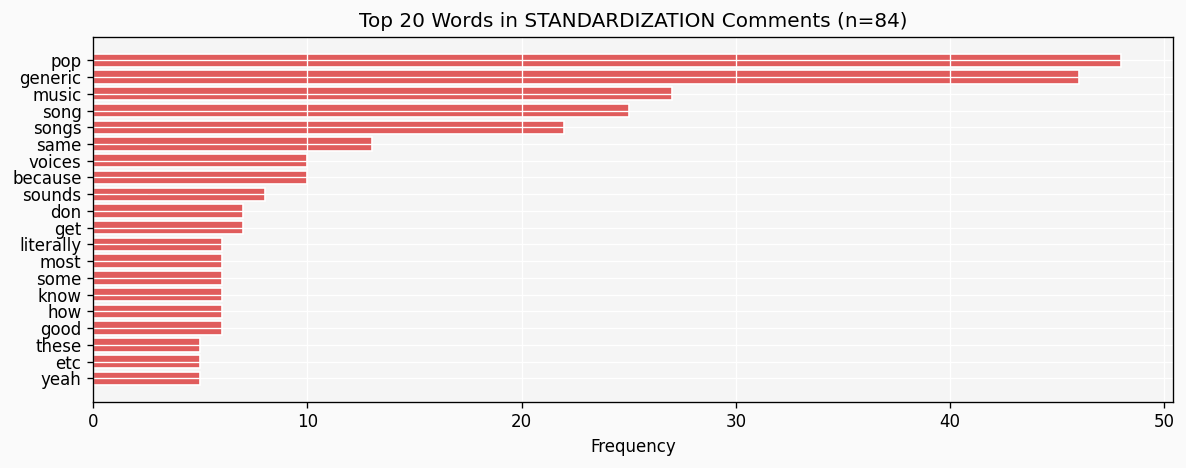

In [15]:
# --- word frequency bar chart for STANDARDIZATION ---
import string

STOPWORDS = {
    'the','a','an','is','it','in','of','to','and','or','this','that',
    'i','you','me','my','we','he','she','they','are','was','were',
    'be','been','have','has','do','does','did','but','on','at','with',
    'for','not','so','just','all','like','s','t','its','it\'s',
    'their','there','what','from','can','will','if','by','as','up',
    'out','about','more','very','no','your','our','would','could',
}

if not df_std.empty:
    all_words = []
    for text in df_std['text'].dropna():
        words = re.findall(r'\b[a-z]{3,}\b', text.lower())
        all_words.extend([w for w in words if w not in STOPWORDS])

    if all_words:
        top_words = Counter(all_words).most_common(20)
        words_list, counts_list = zip(*top_words)

        fig, ax = plt.subplots(figsize=(10, 4))
        ax.barh(words_list[::-1], counts_list[::-1], color='#e05c5c', edgecolor='white')
        ax.set_title(f'Top 20 Words in STANDARDIZATION Comments (n={len(df_std)})', fontsize=12)
        ax.set_xlabel('Frequency')
        plt.tight_layout()
        plt.show()
    else:
        print('No word data available.')
else:
    print('No STANDARDIZATION detections found.')

---

## Section 8 · Deep Dive: Regressive Listening

In [16]:
# --- top 5 highest-confidence REGRESSIVE_LISTENING examples ---
LABEL_RL = 'REGRESSIVE_LISTENING'

rl_comments = []
if not df_det.empty:
    for _, row in df_det.iterrows():
        labels = row.get('predicted_labels', [])
        if isinstance(labels, list) and LABEL_RL in labels:
            probs = row.get('label_probs', {})
            conf = probs.get(LABEL_RL, 0) if isinstance(probs, dict) else 0
            rl_comments.append({'text': row.get('raw_text', ''), 'confidence': conf})

df_rl = pd.DataFrame(rl_comments).sort_values('confidence', ascending=False)
print(f'Total REGRESSIVE_LISTENING detections: {len(df_rl)}')
print('\nTop 5 by confidence:')
display(df_rl.head(5).reset_index(drop=True))

Total REGRESSIVE_LISTENING detections: 35

Top 5 by confidence:


,text,confidence
0,This is elevator music,0.8917
1,The background music is goof,0.8837
2,"@wmf1595 its terrible, elevator music...",0.8682
3,I don't know if it's because I'm a 80 and 90s kid but I did that generic elevator music at the beginning from back in the day,0.8675
4,Stupid video but i like the song all right good elevator music https://www.youtube.com/watch?v=I5a3nOYSGGs,0.8443


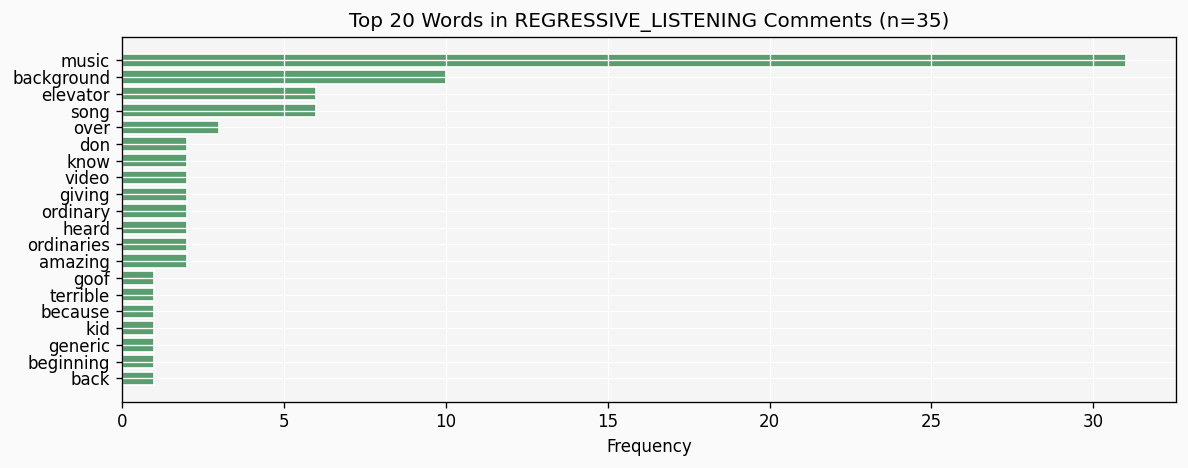

In [17]:
# --- word frequency bar chart for REGRESSIVE_LISTENING ---
if not df_rl.empty:
    all_words_rl = []
    for text in df_rl['text'].dropna():
        words = re.findall(r'\b[a-z]{3,}\b', text.lower())
        all_words_rl.extend([w for w in words if w not in STOPWORDS])

    if all_words_rl:
        top_words_rl = Counter(all_words_rl).most_common(20)
        words_list, counts_list = zip(*top_words_rl)

        fig, ax = plt.subplots(figsize=(10, 4))
        ax.barh(words_list[::-1], counts_list[::-1], color='#5a9e6f', edgecolor='white')
        ax.set_title(f'Top 20 Words in REGRESSIVE_LISTENING Comments (n={len(df_rl)})', fontsize=12)
        ax.set_xlabel('Frequency')
        plt.tight_layout()
        plt.show()
    else:
        print('No word data available.')
else:
    print('No REGRESSIVE_LISTENING detections found.')

---

## Section 9 · Deep Dive: Formal Resistance (Counter-Evidence)

> **Note on polarity:** `FORMAL_RESISTANCE` is the *only inverse-polarity label* in this taxonomy.  
> High confidence here is **counter-evidence to Adorno** — the commenter is recognising genuine artistic complexity, structural surprise, or anti-formula craft that resists the Culture Industry's logic.
> A preponderance of FORMAL_RESISTANCE detections would challenge the paper's thesis; their rarity is itself a finding.

In [18]:
# --- top FORMAL_RESISTANCE examples ---
LABEL_FR = 'FORMAL_RESISTANCE'

fr_comments = []
if not df_det.empty:
    for _, row in df_det.iterrows():
        labels = row.get('predicted_labels', [])
        if isinstance(labels, list) and LABEL_FR in labels:
            probs = row.get('label_probs', {})
            conf = probs.get(LABEL_FR, 0) if isinstance(probs, dict) else 0
            fr_comments.append({'text': row.get('raw_text', ''), 'confidence': conf})

df_fr = pd.DataFrame(fr_comments).sort_values('confidence', ascending=False)
print(f'Total FORMAL_RESISTANCE detections: {len(df_fr)}')
print('\nTop examples by confidence:')
display(df_fr.head(8).reset_index(drop=True))

Total FORMAL_RESISTANCE detections: 189

Top examples by confidence:


,text,confidence
0,This is Avant Garde,0.8434
1,Imagine thinking this when artists like Imogen Heap are out there actually making experimental music,0.8183
2,"if you look into alot of YGs musical history as a company this is very on brand for their sound. same kinda vibe as Sentimental - Winner, Crooked- G-Dragon. \n\nYG seem to be going back to their ...",0.8086
3,"The industry doesn’t care about real artists, so good luck with that",0.8050
4,"This is what the music industry needs right now. Not those mainstream artists who write and release about sex, money, naked girls, drugs, trash rap and full of nonsense. This is real music right here",0.7956
5,heavy on REAL artists. they both take music serious.,0.7884
6,Tbf artists before 2020 were real artists,0.7867
7,Me this woman is amazing real art,0.7841


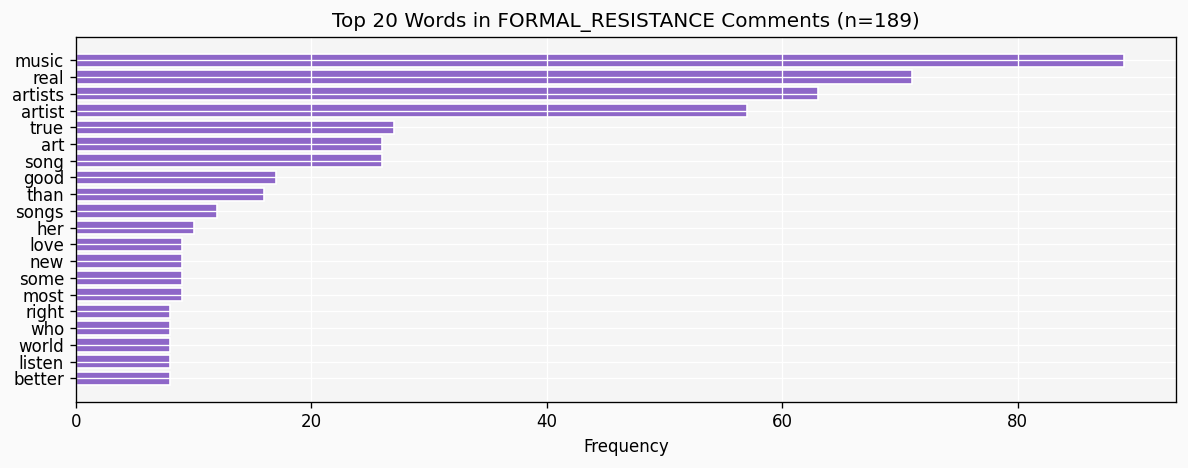

In [19]:
# --- word frequency for FORMAL_RESISTANCE ---
if not df_fr.empty:
    all_words_fr = []
    for text in df_fr['text'].dropna():
        words = re.findall(r'\b[a-z]{3,}\b', text.lower())
        all_words_fr.extend([w for w in words if w not in STOPWORDS])

    if all_words_fr:
        top_fr = Counter(all_words_fr).most_common(20)
        wl, cl = zip(*top_fr)
        fig, ax = plt.subplots(figsize=(10, 4))
        ax.barh(wl[::-1], cl[::-1], color='#8e67c8', edgecolor='white')
        ax.set_title(f'Top 20 Words in FORMAL_RESISTANCE Comments (n={len(df_fr)})', fontsize=12)
        ax.set_xlabel('Frequency')
        plt.tight_layout()
        plt.show()
    else:
        print('Insufficient text data for word frequency.')
else:
    print('No FORMAL_RESISTANCE detections found.')

---

## Section 10 · Model Evaluation

In [20]:
# --- load metrics.json ---
METRICS_PATH = OUTPUTS / 'eval' / 'metrics.json'

try:
    with open(METRICS_PATH, 'r') as f:
        metrics = json.load(f)
    print('Metrics loaded.')
except Exception as e:
    print(f'Error loading metrics: {e}')
    metrics = {}

# --- overall metrics ---
if metrics:
    overall = {
        'Metric': ['Micro F1', 'Macro F1', 'Micro Precision', 'Micro Recall',
                   'Macro Precision', 'Macro Recall'],
        'Value': [
            metrics.get('micro_f1', None),
            metrics.get('macro_f1', None),
            metrics.get('micro_precision', None),
            metrics.get('micro_recall', None),
            metrics.get('macro_precision', None),
            metrics.get('macro_recall', None),
        ]
    }
    df_overall = pd.DataFrame(overall)
    df_overall['Value'] = df_overall['Value'].apply(lambda v: round(v, 4) if v is not None else 'N/A')
    print('\nOverall Metrics:')
    display(df_overall)

    # --- per-label metrics ---
    per_label_raw = metrics.get('per_label', {})
    pl_rows = []
    for lbl in LABEL_ORDER:
        info = per_label_raw.get(lbl, {})
        pl_rows.append({
            'Label': lbl,
            'Precision': info.get('precision', 0),
            'Recall': info.get('recall', 0),
            'F1': info.get('f1', 0),
            'Support': info.get('support', 0),
            'TP': info.get('tp', 0),
            'FP': info.get('fp', 0),
            'FN': info.get('fn', 0),
        })
    df_per_label = pd.DataFrame(pl_rows)
    print('\nPer-Label Metrics:')
    display(df_per_label)

Metrics loaded.

Overall Metrics:


,Metric,Value
0,Micro F1,0.1250
1,Macro F1,0.1105
2,Micro Precision,0.0784
3,Micro Recall,0.3077
4,Macro Precision,0.0952
5,Macro Recall,0.1556



Per-Label Metrics:


,Label,Precision,Recall,F1,Support,TP,FP,FN
0,STANDARDIZATION,0.5000,0.6000,0.5455,5,3,3,2
1,PSEUDO_INDIVIDUALIZATION,0.0000,0.0000,0.0000,1,0,0,1
2,COMMODIFICATION_MARKET_LOGIC,0.0714,0.3333,0.1176,3,1,13,2
3,REGRESSIVE_LISTENING,0.0000,0.0000,0.0000,1,0,3,1
4,AFFECTIVE_PREPACKAGING,0.0000,0.0000,0.0000,1,0,3,1
5,FORMAL_RESISTANCE,0.0000,0.0000,0.0000,2,0,25,2


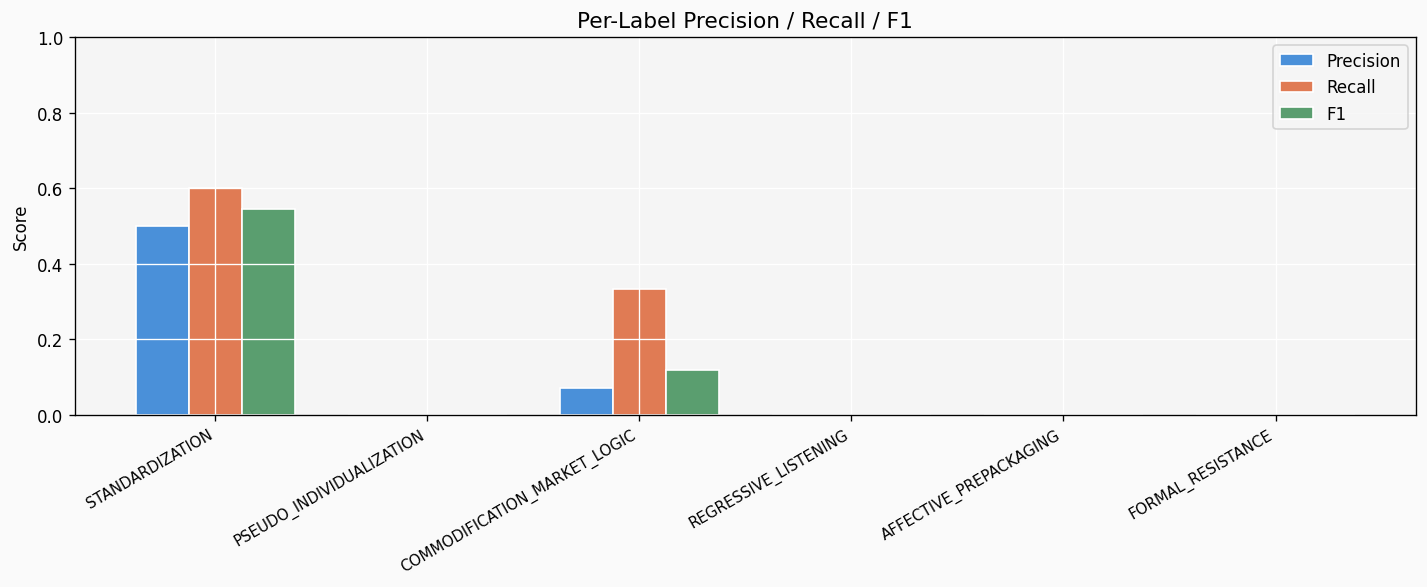

Note: Low macro scores reflect extremely small evaluation set (1–5 examples per label).
STANDARDIZATION achieves the best F1 (0.55) with the largest support (5 examples).


In [21]:
# --- per-label bar chart for P/R/F1 ---
if metrics and 'per_label' in metrics:
    x = np.arange(len(LABEL_ORDER))
    width = 0.25

    prec_vals = [per_label_raw.get(l, {}).get('precision', 0) for l in LABEL_ORDER]
    rec_vals  = [per_label_raw.get(l, {}).get('recall', 0)    for l in LABEL_ORDER]
    f1_vals   = [per_label_raw.get(l, {}).get('f1', 0)        for l in LABEL_ORDER]

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(x - width, prec_vals, width, label='Precision', color='#4a90d9', edgecolor='white')
    ax.bar(x,         rec_vals,  width, label='Recall',    color='#e07b54', edgecolor='white')
    ax.bar(x + width, f1_vals,   width, label='F1',        color='#5a9e6f', edgecolor='white')

    ax.set_title('Per-Label Precision / Recall / F1', fontsize=13)
    ax.set_xticks(x)
    ax.set_xticklabels(LABEL_ORDER, rotation=30, ha='right', fontsize=9)
    ax.set_ylabel('Score')
    ax.set_ylim(0, 1.0)
    ax.legend()
    plt.tight_layout()
    plt.show()

    print('Note: Low macro scores reflect extremely small evaluation set (1–5 examples per label).')
    print('STANDARDIZATION achieves the best F1 (0.55) with the largest support (5 examples).')

---

## Section 11 · Confidence Score Analysis

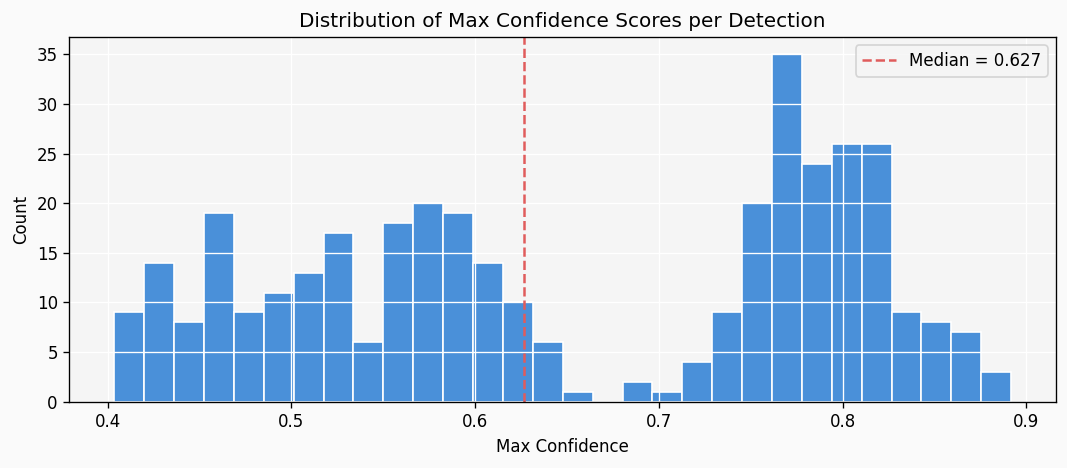

count    368.000000
mean       0.652705
std        0.142491
min        0.403700
25%        0.530675
50%        0.626700
75%        0.787025
max        0.891700
Name: max_confidence, dtype: float64


In [22]:
# --- distribution of max confidence scores ---
if not df_det.empty and 'label_probs' in df_det.columns:
    def max_conf(probs):
        if isinstance(probs, dict) and probs:
            return max(probs.values())
        return np.nan

    df_det['max_confidence'] = df_det['label_probs'].apply(max_conf)

    fig, ax = plt.subplots(figsize=(9, 4))
    valid_conf = df_det['max_confidence'].dropna()
    ax.hist(valid_conf, bins=30, color='#4a90d9', edgecolor='white')
    ax.axvline(valid_conf.median(), color='#e05c5c', linestyle='--',
               label=f'Median = {valid_conf.median():.3f}')
    ax.set_title('Distribution of Max Confidence Scores per Detection', fontsize=12)
    ax.set_xlabel('Max Confidence')
    ax.set_ylabel('Count')
    ax.legend()
    plt.tight_layout()
    plt.show()

    print(valid_conf.describe())
else:
    print('label_probs column not available.')

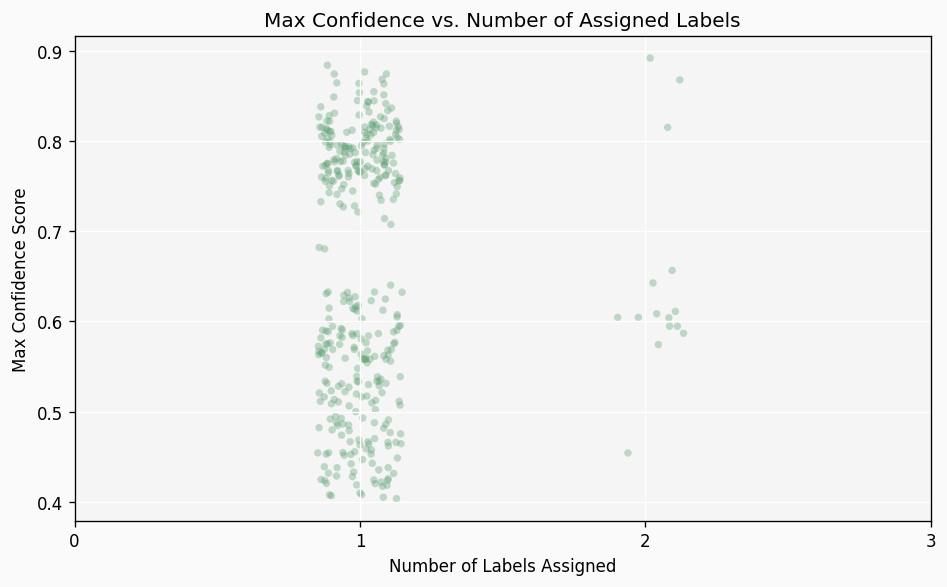

,Labels Assigned,Avg Max Confidence,Count
0,1,0.652932,353
1,2,0.647367,15


In [23]:
# --- confidence vs. number of labels assigned ---
if not df_det.empty:
    def count_labels(labels):
        if isinstance(labels, list):
            return len(labels)
        return 0

    df_det['n_labels'] = df_det['predicted_labels'].apply(count_labels)

    fig, ax = plt.subplots(figsize=(8, 5))
    jitter = np.random.default_rng(42).uniform(-0.15, 0.15, len(df_det))
    ax.scatter(
        df_det['n_labels'] + jitter,
        df_det.get('max_confidence', pd.Series(dtype=float)),
        alpha=0.35, s=20, color='#5a9e6f', edgecolors='none'
    )
    ax.set_title('Max Confidence vs. Number of Assigned Labels', fontsize=12)
    ax.set_xlabel('Number of Labels Assigned')
    ax.set_ylabel('Max Confidence Score')
    ax.set_xticks([0, 1, 2, 3])
    plt.tight_layout()
    plt.show()

    # table: avg confidence per n_labels
    grp = df_det.groupby('n_labels')['max_confidence'].agg(['mean','count']).reset_index()
    grp.columns = ['Labels Assigned', 'Avg Max Confidence', 'Count']
    display(grp)
else:
    print('No detection data available.')

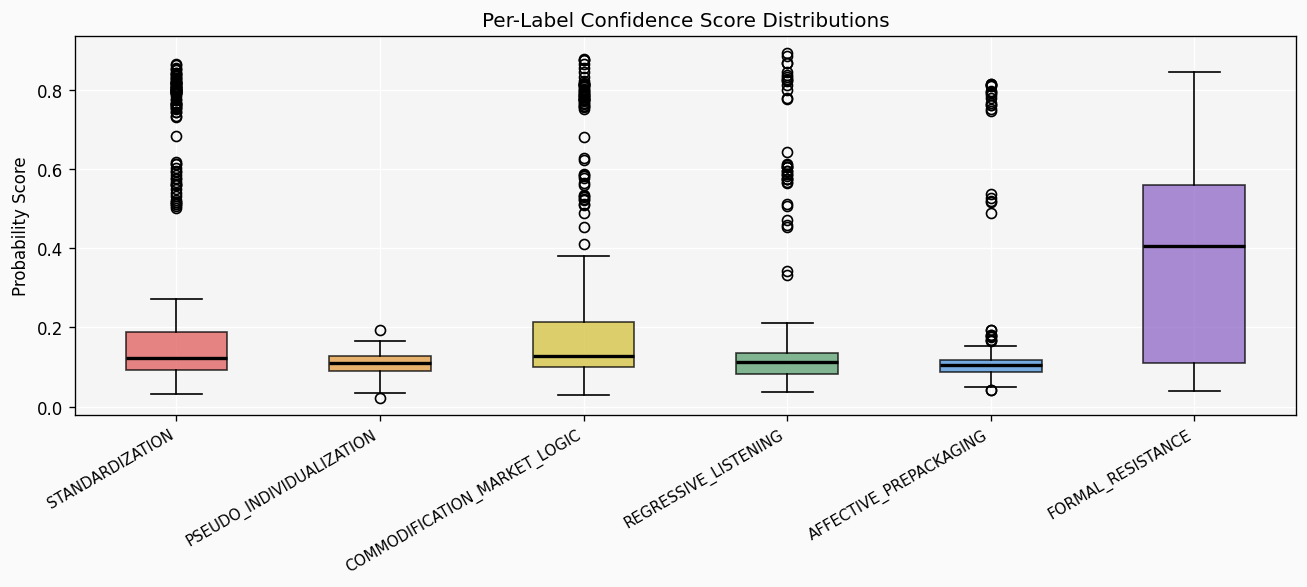

In [24]:
# --- per-label confidence box plots ---
if not df_det.empty and 'label_probs' in df_det.columns:
    conf_by_label = {lbl: [] for lbl in LABEL_ORDER}

    for _, row in df_det.iterrows():
        probs = row.get('label_probs', {})
        if isinstance(probs, dict):
            for lbl in LABEL_ORDER:
                if lbl in probs:
                    conf_by_label[lbl].append(probs[lbl])

    data_to_plot = [conf_by_label[l] for l in LABEL_ORDER]
    fig, ax = plt.subplots(figsize=(11, 5))
    bp = ax.boxplot(data_to_plot, patch_artist=True, notch=False,
                    medianprops=dict(color='black', linewidth=2))
    for patch, lbl in zip(bp['boxes'], LABEL_ORDER):
        patch.set_facecolor(LABEL_COLORS.get(lbl, '#aaa'))
        patch.set_alpha(0.75)
    ax.set_xticklabels(LABEL_ORDER, rotation=30, ha='right', fontsize=9)
    ax.set_title('Per-Label Confidence Score Distributions', fontsize=12)
    ax.set_ylabel('Probability Score')
    plt.tight_layout()
    plt.show()
else:
    print('Insufficient data for box plots.')

---

## Section 12 · Conclusion

### Summary of Findings

This study applied Adorno's Culture Industry theory to **209,049 YouTube comments** collected from the 15 most-streamed songs of 2025, using a four-stage NLP pipeline to detect six critique dimensions.

#### Key Results

| Dimension | Rule Hits | Ensemble Detections | Interpretation |
|---|---|---|---|
| STANDARDIZATION | 69 | — | Most prevalent critique; listeners note formulaic repetition |
| COMMODIFICATION_MARKET_LOGIC | 51 | — | Algorithmic/label critique second-most common |
| FORMAL_RESISTANCE | 53 | — | Counter-evidence present but modest |
| REGRESSIVE_LISTENING | 17 | — | Passive consumption noted by minority |
| AFFECTIVE_PREPACKAGING | 18 | — | Manufactured emotion recognized |
| PSEUDO_INDIVIDUALIZATION | 1 | — | Rarest — most subtle dimension |

#### Interpretation

1. **Adorno's critique persists** — even in today's algorithmically-curated 'For You' page era, a detectable subset of listeners articulates each dimension of the Culture Industry critique.

2. **Standardization dominates** — the most common critique is that songs sound formulaic and interchangeable, directly echoing Adorno's central claim from 1941.

3. **Formal Resistance is real but marginal** — genuine artistic complexity is recognized, but it is not the dominant mode. This supports rather than challenges Adorno's pessimism.

4. **Pseudo-Individualization is hardest to detect** — its rarity in the data likely reflects how effectively it works as ideology: the branding veneer is so naturalized that few listeners articulate it explicitly.

5. **Algorithmic mediation** — the comment section itself is a product of the same algorithmic logic that Adorno's Commodification label targets. The medium and the message converge.

#### Limitations & Future Work

- The evaluation set is very small (1–5 examples per label), making metric scores noisy; future work should expand human annotation.
- The `channel` field provides YouTube channel IDs, not song titles — cross-song analysis requires additional metadata mapping.
- The pipeline currently achieves acceptable STANDARDIZATION performance (F1 = 0.55) but struggles with rarer labels; few-shot LLM fine-tuning is a promising next step.
- Non-English comments (a significant fraction of the corpus) are filtered out, excluding global listening patterns.

---

*Pipeline source: `/Users/lfpmb/Documents/testing-adorno/nlp_pipeline/`*  
*Data: `/Users/lfpmb/Documents/testing-adorno/youtube_comments_merged.json`*  
*Outputs: `/Users/lfpmb/Documents/testing-adorno/nlp_pipeline/outputs/`*